C:\Users\Lenovo\AppData\Local\Temp\ipykernel_211984\425147196.py:29: DtypeWarning: Columns (18) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_211984\425147196.py:181: DtypeWarning: Columns (18) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv(FILE_AB)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_211984\425147196.py:184: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  if "HFP_mean" in df.colu


MixedLM summary for IUCN = LC
            Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: slope_abundance
No. Observations: 12768   Method:             REML           
No. Groups:       21      Scale:              0.0625         
Min. group size:  11      Log-Likelihood:     -535.6741      
Max. group size:  3340    Converged:          Yes            
Mean group size:  608.0                                      
-------------------------------------------------------------
                   Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------
Intercept          -0.012    0.007 -1.715 0.086 -0.026  0.002
slope_temp_z        0.004    0.002  1.574 0.116 -0.001  0.009
elevation_z        -0.002    0.003 -0.669 0.504 -0.008  0.004
HFP_mean_z          0.005    0.003  1.752 0.080 -0.001  0.011
mean_temp_z         0.002    0.005  0.374 0.709 -0.008  0.012
mean_flow_z         0.006    0.002  2.411 0.016  0.

d:\software1\anaconda3\envs\newbase\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_211984\425147196.py:290: DtypeWarning: Columns (18) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv(folder+"/Abundance_slope_with_traits_clean.csv")
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_211984\425147196.py:293: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub["n_obs"]=sub["n_obs"].fillna(1)



MixedLM summary for IUCN = CR
            Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: slope_abundance
No. Observations: 1740    Method:             REML           
No. Groups:       1       Scale:              0.0576         
Min. group size:  1740    Log-Likelihood:     -24.6508       
Max. group size:  1740    Converged:          Yes            
Mean group size:  1740.0                                     
-------------------------------------------------------------
                   Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------
Intercept          -0.081    0.025 -3.190 0.001 -0.131 -0.031
slope_temp_z       -0.009    0.006 -1.553 0.120 -0.021  0.002
elevation_z        -0.004    0.011 -0.348 0.728 -0.026  0.018
HFP_mean_z          0.023    0.008  2.993 0.003  0.008  0.038
mean_temp_z        -0.041    0.016 -2.610 0.009 -0.072 -0.010
mean_flow_z         0.021    0.007  2.963 0.003  0.

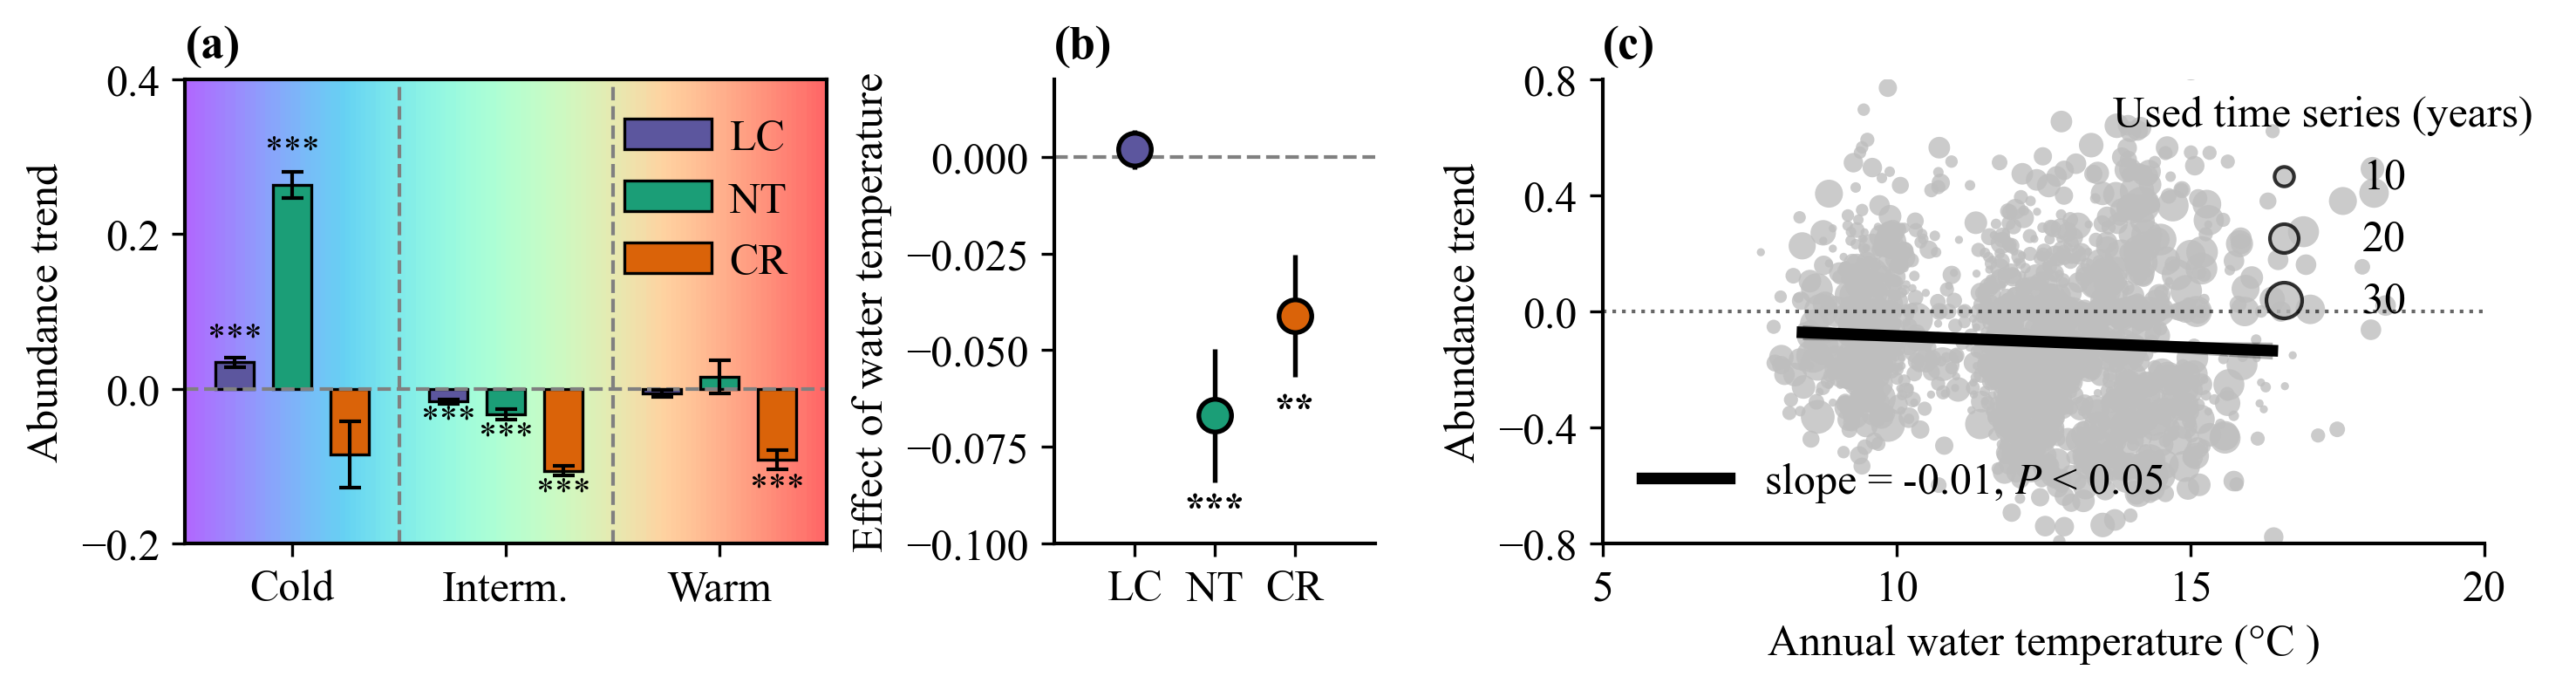

In [ ]:
# -*- coding: utf-8 -*- (Dataset S6)
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import statsmodels.api as sm
import matplotlib.pyplot as plt
import os
from scipy.stats import ttest_1samp
import cmaps
import matplotlib.gridspec as gridspec

plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 12,
    "axes.linewidth": 1,
    "mathtext.fontset": "stix",
})

fig = plt.figure(figsize=(10,2.8),dpi=300)  
gs = fig.add_gridspec(1,3,width_ratios=[8,4,11])

ax1 = fig.add_subplot(gs[0])  
ax2 = fig.add_subplot(gs[1])
ax3 = fig.add_subplot(gs[2])

ax = ax1

file = r"D:\NC\Data\rivernet\inputdata\Abundance_slope_with_traits_clean.csv"
df = pd.read_csv(file)

cols = ["SiteID", "Species", "slope_abundance", "zone",'IUCN']
df = df[cols].dropna()

df["Species"] = df["Species"].astype(str)
df["zone"] = df["zone"].astype(str)

IUCN_LEVELS = ["LC", "NT", "CR"]
df = df[df["IUCN"].isin(IUCN_LEVELS)]

def mean_se_p(sub):
    mean = sub.mean()
    se = sub.std(ddof=1) / np.sqrt(len(sub))
    _, p = ttest_1samp(sub, 0.0)
    return mean, se, p

def p_to_star(p):
    if p < 0.001: return "***"
    elif p < 0.01: return "**"
    elif p < 0.05: return "*"
    else: return ""
zones = ["Cold", "Intermediate", "Warm"]
rows = []
for zone in zones:

    df_zone = df[df["zone"] == zone]

    for ic in IUCN_LEVELS:

        sub = df_zone[df_zone["IUCN"] == ic]["slope_abundance"]

        mean, se, p = mean_se_p(sub)

        rows.append([zone, ic, mean, se, p])

res = pd.DataFrame(rows, columns=["Zone", "IUCN", "Mean", "SE", "P"])
res["Zone"] = pd.Categorical(res["Zone"], categories=zones, ordered=True)
res = res.sort_values("Zone")

xmin, xmax = -0.5, 2.5 
ymin, ymax = -0.2, 0.4     

grad = np.tile(np.linspace(0, 1, 800), (200, 1))
cmap = cmaps.MPL_rainbow  

ax.imshow(
    grad,
    extent=[xmin, xmax, ymin, ymax],
    origin="lower",
    cmap=cmap,
    alpha=0.6,
    zorder=0,
    aspect="auto"
)

bar_width = 0.18
gap = 1.5

colors = {
    "LC": "#5c569e",
    "NT": "#1b9e77",
    "CR": "#da6309",
}

offsets = {
    "LC": -1 * bar_width * gap,
    "NT": 0 * bar_width * gap,
    "CR":  1 * bar_width * gap,
}

handles = {}

for _, row in res.iterrows():

    zone_idx = zones.index(row["Zone"])

    x = zone_idx + offsets[row["IUCN"]]

    bar = ax.bar(
        x,
        row["Mean"],
        width=bar_width,
        color=colors[row["IUCN"]],
        edgecolor="black",
        linewidth=0.8,
        zorder=2
    )

    ax.errorbar(
        x,
        row["Mean"],
        yerr=row["SE"],
        fmt="none",
        ecolor="black",
        elinewidth=1,
        capsize=3,
        zorder=3
    )

    star = p_to_star(row["P"])

    if star != "":
        offset = row["SE"] * 1.3
        y = row["Mean"] + offset if row["Mean"] >= 0 else row["Mean"] - offset

        ax.text(
            x,
            y,
            star,
            ha="center",
            va="bottom" if row["Mean"] >= 0 else "top",
            fontsize=10
        )

    if row["IUCN"] not in handles:
        handles[row["IUCN"]] = bar

ax.axhline(0, linestyle="--", color="gray", linewidth=1)

for v in [0.5, 1.5, 2.5]:
    ax.axvline(v, linestyle="--", color="gray", linewidth=1)

ax.set_xticks(range(len(zones)))
ax.set_xticklabels(["Cold","Interm.","Warm"])

ax.set_ylabel("Abundance trend")

ax.legend(
    handles.values(),
    handles.keys(),
    frameon=False,
    loc="upper right",
    # bbox_to_anchor=(-0.04, 0.98),
    markerscale=0.7,
    handletextpad=0.4,
)

ax.set_title("(a)", loc="left", fontsize=13, fontweight="bold")

ax.set_ylim(-0.2, 0.4)
ax.set_yticks([-0.2, 0.0, 0.2, 0.4])

#######################################################################
# =========================== 图 (b) ==========================
#######################################################################
ax = ax2

FILE_AB=r"D:\NC\Data\rivernet\inputdata\Abundance_slope_with_traits_clean.csv"
IUCN_LEVELS=["LC","NT","CR"];TARGET_TERM="mean_temp_z"
COLORS={"LC":"#5c569e","NT":"#1b9e77","CR":"#da6309"}

df=pd.read_csv(FILE_AB)
df["SiteID"]=df["SiteID"].astype(str)
df["Species"]=df["Species"].astype(str)
if "HFP_mean" in df.columns: df["HFP_mean"].replace([-np.inf,np.inf],np.nan,inplace=True)
df = df[df["IUCN"].isin(IUCN_LEVELS)]

cols=["slope_abundance","slope_temp","elevation","HFP_mean","mean_temp","mean_flow","mean_salinity","mean_organic"]
df[cols]=df[cols].apply(pd.to_numeric,errors="coerce")
df=df.dropna(subset=cols+["Species","Protocol","zone","IUCN"]).copy()
for c in ["slope_temp","elevation","HFP_mean","mean_temp","mean_flow","mean_salinity","mean_organic"]:
    df[c+"_z"]=(df[c]-df[c].mean())/df[c].std()

def fit_mixedlm(d):
    f = (
        "slope_abundance ~ "
        "slope_temp_z + elevation_z + HFP_mean_z + "
        "mean_temp_z + mean_flow_z + mean_salinity_z + mean_organic_z"
    )
    vc = {}
    if "Protocol" in d.columns and d["Protocol"].nunique() > 1:
        vc["Protocol"] = "0 + C(Protocol)"
    if "HYBAS_ID" in d.columns and d["HYBAS_ID"].nunique() > 1:
        vc["HYBAS_ID"] = "0 + C(HYBAS_ID)"

    if len(vc) == 0:
        vc = None
    return smf.mixedlm(
        f,
        data=d,
        groups=d["Species"],  
        vc_formula=vc
    ).fit(
        reml=True,
        method="powell",
        maxiter=300
    )

def extract(m,t): fe=m.fe_params;bse=m.bse_fe;pv=m.pvalues;return fe.get(t,np.nan),bse.get(t,np.nan),pv.get(t,np.nan)

rows=[]
for ic in IUCN_LEVELS:
    sub=df[df["IUCN"]==ic]
    if len(sub)<10:
        rows.append([ic,np.nan,np.nan,np.nan])
        continue
    try:
        m = fit_mixedlm(sub)
        print("\n" + "="*80)
        print(f"MixedLM summary for IUCN = {ic}")
        print("="*80)
        print(m.summary())
        coef,se,p = extract(m, TARGET_TERM)
        rows.append([ic,coef,se,p])
    except Exception as e:
        print(f"❌ Model failed for IUCN = {ic}: {e}")
        rows.append([ic,np.nan,np.nan,np.nan])


res_b=pd.DataFrame(rows,columns=["IUCN","Coef","SE","P"])

pos={"LC":-0.04,"NT":0,"CR":0.04}
def p_to_star(p):return "***"if p<0.001 else"**"if p<0.01 else"*"if p<0.05 else""


def annotate_star(ax,x,y,p):
    star=p_to_star(p)
    if star!="":
        ax.text(x, y+(0.01 if y>=0 else -0.02), star,
                ha="center", va="bottom" if y>=0 else "top",
                fontsize=11,fontweight="bold")
for _, row in res_b.iterrows(): 
    if pd.isna(row["Coef"]) or pd.isna(row["SE"]):
        continue
    x = pos[row["IUCN"]]
    ax.errorbar(
        x, row["Coef"],
        yerr=row["SE"],
        fmt="o",
        markerfacecolor=colors[row["IUCN"]],
        markeredgecolor="black",
        markeredgewidth=1.3,
        markersize=9,
        ecolor="black",
        elinewidth=1.3,
        capsize=0,
        zorder=3
    )
    annotate_star(ax, x, row["Coef"], row["P"])
ax.axhline(0, ls="--", c="gray", lw=1)

ax.set_xlim(-0.08,0.08)
ax.set_ylim(-0.1,0.02)
# ax.set_yticks([-0.1,-0.05,0,0.02])
ax.set_xticks([-0.04,0,0.04])
ax.set_xticklabels(["LC","NT","CR"])

ax.set_ylabel("Effect of water temperature")
ax.set_title("(b)",loc="left",fontsize=13,fontweight="bold")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)



#######################################################################
# =========================== 图 (c)==========================
#######################################################################
ax = ax3

folder=r"D:\NC\Data\rivernet\inputdata"
df=pd.read_csv(folder+"/Abundance_slope_with_traits_clean.csv")
sp="Anguilla anguilla"
sub=df[(df["Species"]==sp)]
sub["n_obs"]=sub["n_obs"].fillna(1)

s_min,s_max=5,100;n_all=sub["n_obs"].values
n_norm=(n_all-n_all.min())/(n_all.max()-n_all.min())if n_all.max()>n_all.min()else np.ones_like(n_all)
sizes=s_min+n_norm*(s_max-s_min)

x=sub["mean_temp"].values;y=sub["slope_abundance"].values
mask=(~np.isnan(x))&(~np.isnan(y));x,y=x[mask],y[mask]

ax.scatter(x,y,s=sizes[mask],color="#bebebe",alpha=0.8,zorder=1,linewidths=0)
X=sm.add_constant(x);model=sm.OLS(y,X).fit()
x_pred=np.linspace(np.percentile(x,1),np.percentile(x,99),200)
pred=model.get_prediction(sm.add_constant(x_pred)).summary_frame(alpha=0.05)
y_mean,y_low,y_high=pred["mean"],pred["mean_ci_lower"],pred["mean_ci_upper"]

slope=model.params[1];p_val=model.pvalues[1]
if p_val < 0.001:
    p_str = "$P$ < 0.001"
elif p_val < 0.01:
    p_str = "$P$ < 0.01"
elif p_val < 0.05:
    p_str = "$P$ < 0.05"
else:
    p_str = f"$P$ = {p_val:.2f}"

ax.plot(
    x_pred,
    y_mean,
    color="black",
    lw=3.2,
    zorder=4,
    label=f"slope = {slope:.2f}, {p_str}"
)
ax.fill_between(x_pred,y_low,y_high,color="black",alpha=0.3,zorder=3,linewidth=0)
ax.axhline(0,color="black",lw=1,ls=":",alpha=0.6)
ax.set_xlabel("Annual water temperature (°C )")
ax.set_ylabel("Abundance trend")
ax.set_xlim(5,20)
ax.set_xticks([5,10,15,20])
ax.set_ylim(-0.8,0.8)
ax.set_yticks([-0.8,-0.4,0,0.4,0.8])
ax.set_title("(c)",loc="left",fontsize=13,fontweight="bold")

legend_line=ax.legend(frameon=False,fontsize=12,loc="lower left")

size_levels=[10,20,30]
def size_map(n,nref):return s_min+(n-nref.min())/(nref.max()-nref.min())*(s_max-s_min)if nref.max()>nref.min()else np.full_like(n,s_min)

handles=[];labels=[]
for v in size_levels:
    s=size_map(np.array([v]),n_all)[0]
    h=ax.scatter([],[],s=s,facecolor="#bebebe",edgecolor="black",alpha=0.8,linewidths=1)
    handles.append(h);labels.append(f"{v}")

ax.legend(
    handles, labels,
    title="Used time series (years)",
    loc="upper right",
    bbox_to_anchor=(1.1, 1.05), 
    frameon=False
)
ax.add_artist(legend_line)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


#######################################################################
plt.tight_layout()
plt.savefig(r"C:\Users\Lenovo\Desktop\6a-c.png",dpi=300)
plt.show()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_211984\3199213372.py:41: DtypeWarning: Columns (18) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_211984\3199213372.py:143: DtypeWarning: Columns (18) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv(FILE_AB)
d:\software1\anaconda3\envs\newbase\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
d:\software1\anaconda3\envs\newbase\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


            Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: slope_abundance
No. Observations: 14683   Method:             REML           
No. Groups:       19      Scale:              0.0617         
Min. group size:  1       Log-Likelihood:     -561.4399      
Max. group size:  3319    Converged:          Yes            
Mean group size:  772.8                                      
-------------------------------------------------------------
                   Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------
Intercept          -0.011    0.009 -1.273 0.203 -0.029  0.006
slope_temp_z        0.001    0.002  0.545 0.586 -0.003  0.006
elevation_z        -0.002    0.003 -0.507 0.612 -0.007  0.004
HFP_mean_z          0.007    0.003  2.405 0.016  0.001  0.012
mean_temp_z        -0.008    0.005 -1.583 0.113 -0.019  0.002
mean_flow_z         0.008    0.002  3.467 0.001  0.004  0.013
mean_salinity_z     

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_211984\3199213372.py:234: DtypeWarning: Columns (18) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv(folder+"/Abundance_slope_with_traits_clean.csv")
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_211984\3199213372.py:237: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub["n_obs"]=sub["n_obs"].fillna(1)


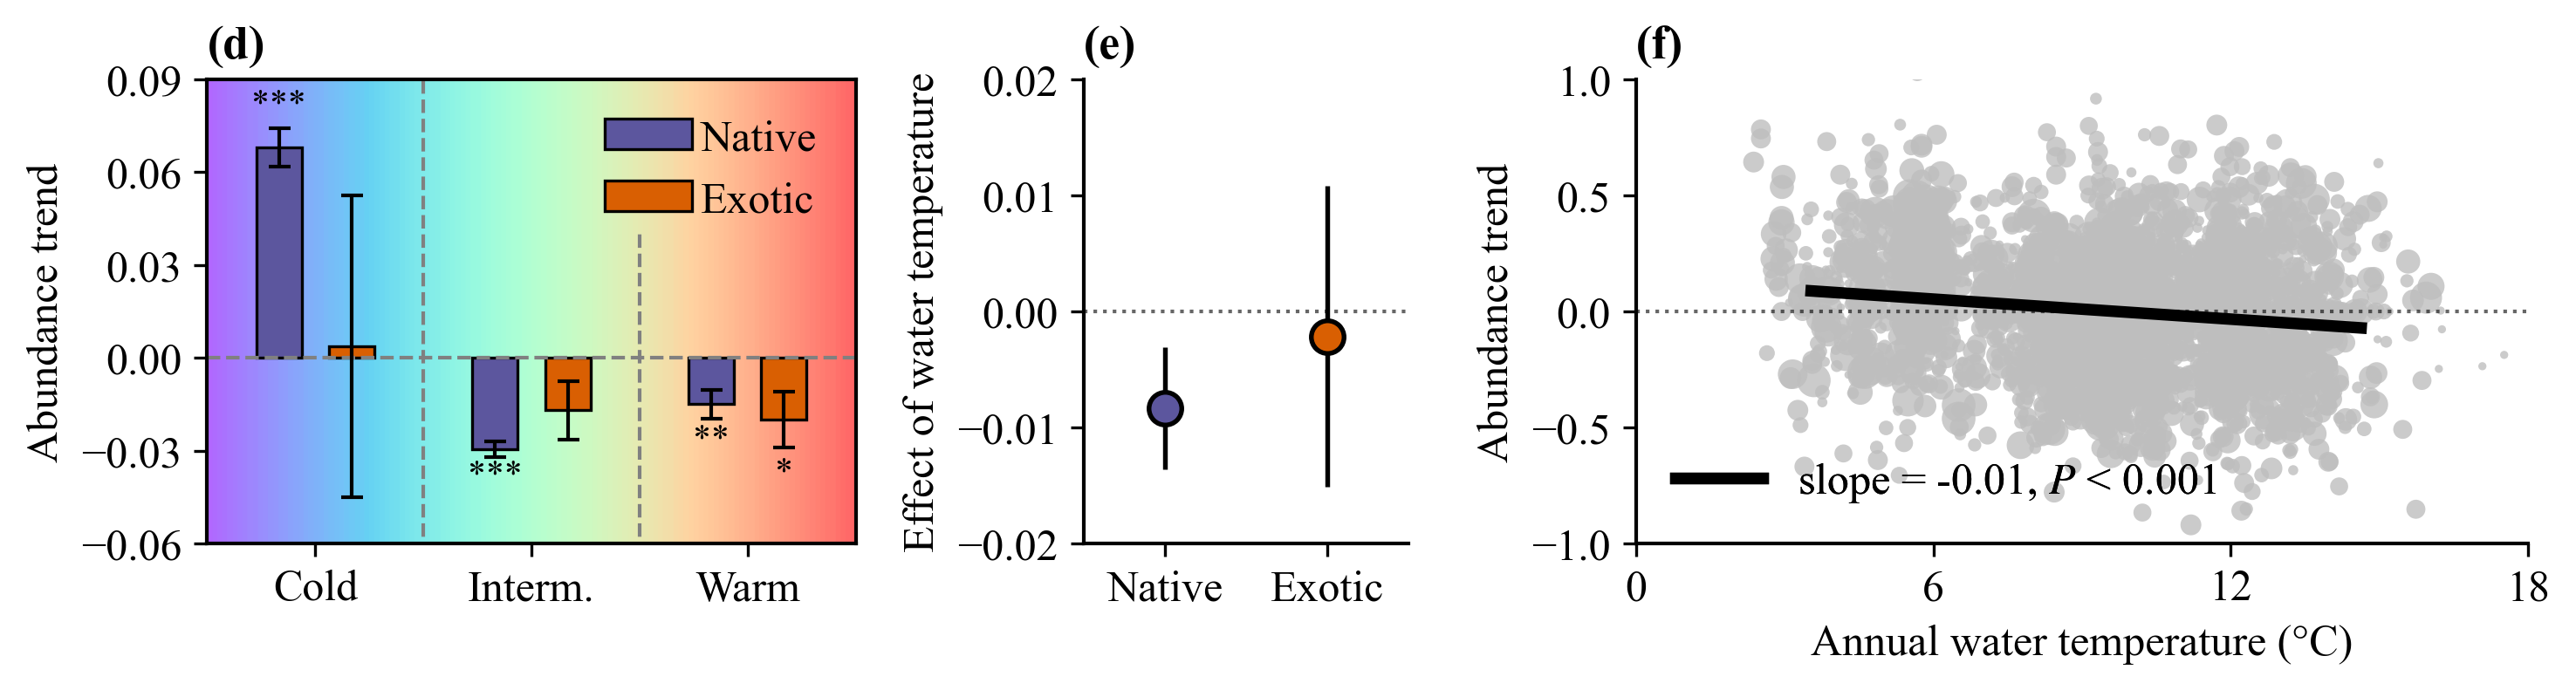

In [ ]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import statsmodels.api as sm
import matplotlib.pyplot as plt
import os
from scipy.stats import ttest_1samp
import cmaps
import matplotlib.gridspec as gridspec

plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 12,
    "axes.linewidth": 1,
    "mathtext.fontset": "stix",  

})

def mean_se_p(sub):
    mean = sub.mean()
    se = sub.std(ddof=1) / np.sqrt(len(sub))
    _, p = ttest_1samp(sub, 0.0)
    return mean, se, p

def p_to_star(p):
    if p < 0.001: return "***"
    elif p < 0.01: return "**"
    elif p < 0.05: return "*"
    else: return ""

fig = plt.figure(figsize=(10,2.8),dpi=300)  
gs = fig.add_gridspec(1,3,width_ratios=[8,4,11])

ax1 = fig.add_subplot(gs[0])  
ax2 = fig.add_subplot(gs[1])
ax3 = fig.add_subplot(gs[2])

ax = ax1
file = r"D:\NC\Data\rivernet\inputdata\Abundance_slope_with_traits_clean.csv"
df = pd.read_csv(file)

cols = ["SiteID","Species","slope_abundance","slope_temp","zone","NativeStatus_final"]
df = df[cols].dropna()
df["Species"] = df["Species"].astype(str)
df["NativeStatus_final"] = df["NativeStatus_final"].astype(str)
df["zone"] = df["zone"].astype(str)

zones = ["Cold","Intermediate","Warm"]   
groups=["native","exotic"]                    
rows=[]
for zone in zones:
    df_zone = df if zone=="All" else df[df["zone"]==zone]
    for st in groups:
        sub = df_zone[df_zone["NativeStatus_final"]==st]["slope_abundance"]
        if len(sub)==0:
            rows.append([zone,st,np.nan,np.nan,np.nan])
            continue
        mean,se,p=mean_se_p(sub)
        rows.append([zone,st,mean,se,p])

res=pd.DataFrame(rows,columns=["Zone","Group","Mean","SE","P"])
res["Zone"]=pd.Categorical(res["Zone"],categories=zones,ordered=True)
res=res.sort_values("Zone")

xmin, xmax = -0.5, 2.5 
ymin, ymax = -0.06, 0.09     
grad = np.tile(np.linspace(0, 1, 800), (200, 1))
cmap = cmaps.MPL_rainbow   
ax.imshow(
    grad,
    extent=[xmin, xmax, ymin, ymax],
    origin="lower",
    cmap=cmap,
    alpha=0.6,
    zorder=0,
    aspect="auto"
)
bar_width = 0.21
gap = 0.8
colors={"native":"#5c569e","exotic":"#d95f02"}  
offsets={"native":-bar_width*gap,"exotic":bar_width*gap}
handles = {}

for _,row in res.iterrows():
    zone_idx=zones.index(row["Zone"])
    x=zone_idx+offsets[row["Group"]]

    bar=ax.bar(
        x,row["Mean"],width=bar_width,color=colors[row["Group"]],
        edgecolor="black",linewidth=0.8,zorder=2
    )
    ax.errorbar(
        x,row["Mean"],yerr=row["SE"],fmt="none",
        ecolor="black",elinewidth=1,capsize=3,zorder=3
    )

    star=p_to_star(row["P"])
    if star!="":
        offset=row["SE"]*1.3
        y=row["Mean"]+offset if row["Mean"]>=0 else row["Mean"]-offset
        ax.text(x,y,star,ha="center",
                va="bottom" if row["Mean"]>=0 else "top",
                fontsize=10)

    if row["Group"] not in handles: handles[row["Group"]]=bar

ax.axhline(0, linestyle="--", color="gray", linewidth=1)
# for v in [1.5, 2.5]:
#     ax.axvline(v, linestyle="--", color="gray", linewidth=1)
ax.vlines(0.5, -5, 0.09, colors="gray", linestyles="--", linewidth=1)
ax.vlines(1.5, -5, 0.04, colors="gray", linestyles="--", linewidth=1)
ax.set_xticks(range(len(zones)))
ax.set_xticklabels(["Cold","Interm.","Warm"])
ax.set_ylabel("Abundance trend")
ax.legend(
    handles.values(),
    [h.capitalize() for h in handles.keys()],
    frameon=False,
    loc="upper right",
    # bbox_to_anchor=(-0.04, 0),
    markerscale=0.3, 
    handletextpad=0.2, 
)
ax.set_title("(d)", loc="left", fontsize=13, fontweight="bold")
ax.set_ylim(-0.06, 0.09)
ax.set_yticks([-0.06, -0.03, 0.0, 0.03, 0.06,0.09])

#######################################################################
# =========================== 图 (b) ==========================
ax = ax2

import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

FILE_AB=r"D:\NC\Data\rivernet\inputdata\Abundance_slope_with_traits_clean.csv"

groups=["native","exotic"]                               
TARGET_TERM="mean_temp_z"
COLORS={"native":"#5c569e","exotic":"#d95f02"}

df=pd.read_csv(FILE_AB)

cols=["SiteID","Species","slope_abundance","slope_temp","zone","NativeStatus_final",
     "elevation","HFP_mean","mean_temp","mean_flow","mean_salinity","mean_organic",'Protocol','p_temp','HYBAS_ID']

df=df[cols].dropna()
df["Species"]=df["Species"].astype(str)
df=df[df["NativeStatus_final"].isin(groups)].copy()

num_cols=["slope_abundance","slope_temp","elevation","HFP_mean",
          "mean_temp","mean_flow","mean_salinity","mean_organic"]
df[num_cols]=df[num_cols].apply(pd.to_numeric,errors="coerce")
df=df.dropna(subset=num_cols+["Species","zone","NativeStatus_final"]).copy()
for c in ["slope_temp","elevation","HFP_mean","mean_temp",
          "mean_flow","mean_salinity","mean_organic"]:
    df[c+"_z"]=(df[c]-df[c].mean())/df[c].std()

def fit_mixedlm(d):
    f = (
        "slope_abundance ~ "
        "slope_temp_z + elevation_z + HFP_mean_z + "
        "mean_temp_z + mean_flow_z + mean_salinity_z + mean_organic_z"
    )
    vc = {}
    if "Protocol" in d.columns and d["Protocol"].nunique() > 1:
        vc["Protocol"] = "0 + C(Protocol)"
    if "HYBAS_ID" in d.columns and d["HYBAS_ID"].nunique() > 1:
        vc["HYBAS_ID"] = "0 + C(HYBAS_ID)"

    if len(vc) == 0:
        vc = None
    return smf.mixedlm(
        f,
        data=d,
        groups=d["Species"],  
        vc_formula=vc
    ).fit(
        reml=True,
        method="powell",
        maxiter=300
    )

def extract(m,t):return m.fe_params.get(t,np.nan),m.bse_fe.get(t,np.nan),m.pvalues.get(t,np.nan)
rows=[]
for st in groups:
    sub=df[df["NativeStatus_final"]==st]
    if len(sub)<10:
        rows.append([st,np.nan,np.nan,np.nan]);continue
    try: m=fit_mixedlm(sub);print(m.summary());coef,se,p=extract(m,TARGET_TERM);rows.append([st,coef,se,p])
    except: rows.append([st,np.nan,np.nan,np.nan])

res_b=pd.DataFrame(rows,columns=["Group","Coef","SE","P"])

pos={"native":-0.03,"exotic":0.03}
def p_to_star(p):return "***"if p<0.001 else"**"if p<0.01 else"*"if p<0.05 else""
def annotate_star(ax,x,y,p):
    st=p_to_star(p)
    if st!="": ax.text(x,y+(0.01 if y>=0 else -0.005),st,ha="center",
                       va="bottom"if y>=0 else"top",fontsize=11,fontweight="bold")

for _,row in res_b.iterrows():
    if pd.isna(row["Coef"]) or pd.isna(row["SE"]): continue

    x=pos[row["Group"]]
    ax.errorbar(
        x,row["Coef"],yerr=row["SE"],fmt="o",
        markerfacecolor=COLORS[row["Group"]],
        markeredgecolor="black",markeredgewidth=1.3,
        markersize=9,ecolor="black",elinewidth=1.3,
        capsize=0,zorder=3
    )
    annotate_star(ax,x,row["Coef"],row["P"])
ax.set_xlim(-0.06,0.06)                      
ax.set_xticks([-0.03,0.03])
ax.set_xticklabels(["Native","Exotic"])
ax.axhline(0,color="black",lw=1,ls=":",alpha=0.6)

ax.set_ylim(-0.02,0.02)
ax.set_yticks([-0.02,-0.01,0,0.01,0.02])

ax.set_ylabel("Effect of water temperature")
ax.set_title("(e)",loc="left",fontsize=13,fontweight="bold")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

#######################################################################
# =========================== 图 (c)==========================
#######################################################################
ax = ax3

folder=r"D:\NC\Data\rivernet\inputdata"
df=pd.read_csv(folder+"/Abundance_slope_with_traits_clean.csv")
sp="Salmo trutta"
sub=df[(df["Species"]==sp)]
sub["n_obs"]=sub["n_obs"].fillna(1)

s_min,s_max=5,100;n_all=sub["n_obs"].values
n_norm=(n_all-n_all.min())/(n_all.max()-n_all.min())if n_all.max()>n_all.min()else np.ones_like(n_all)
sizes=s_min+n_norm*(s_max-s_min)

x=sub["mean_temp"].values;y=sub["slope_abundance"].values
mask=(~np.isnan(x))&(~np.isnan(y));x,y=x[mask],y[mask]

ax.scatter(x,y,s=sizes[mask],color="#bebebe",alpha=0.8,zorder=1,linewidths=0)
X=sm.add_constant(x);model=sm.OLS(y,X).fit()
x_pred=np.linspace(np.percentile(x,1),np.percentile(x,99),200)
pred=model.get_prediction(sm.add_constant(x_pred)).summary_frame(alpha=0.05)
y_mean,y_low,y_high=pred["mean"],pred["mean_ci_lower"],pred["mean_ci_upper"]

slope=model.params[1];p_val=model.pvalues[1]
if p_val < 0.001:
    p_str = "$P$ < 0.001"
elif p_val < 0.01:
    p_str = "$P$ < 0.01"
elif p_val < 0.05:
    p_str = "$P$ < 0.05"
else:
    p_str = f"$P$ = {p_val:.2f}"

ax.plot(
    x_pred,
    y_mean,
    color="black",
    lw=3.2,
    zorder=4,
    label=f"slope = {slope:.2f}, {p_str}"
)
ax.fill_between(x_pred,y_low,y_high,color="black",alpha=0.3,zorder=3,linewidth=0)
ax.axhline(0,color="black",lw=1,ls=":",alpha=0.6)
ax.set_xlabel("Annual water temperature (°C)")
ax.set_ylabel("Abundance trend")
ax.set_xlim(0,18)
ax.set_xticks([0,6,12,18])
ax.set_ylim(-1,1)
ax.set_yticks([-1,-0.5,0,0.5,1])
ax.set_title("(f)",loc="left",fontsize=13,fontweight="bold")

legend_line=ax.legend(frameon=False,fontsize=12,loc="lower left")
ax.add_artist(legend_line)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


#######################################################################
plt.tight_layout()
plt.savefig(r"C:\Users\Lenovo\Desktop\6d-f.png",dpi=300)
plt.show()


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_211984\3971490024.py:40: DtypeWarning: Columns (18) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_211984\3971490024.py:141: DtypeWarning: Columns (18) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv(FILE_AB)
d:\software1\anaconda3\envs\newbase\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
d:\software1\anaconda3\envs\newbase\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
d:\software1\anaconda3\envs\newbase\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated par


MixedLM summary for Strategy = Opportunistic
            Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: slope_abundance
No. Observations: 6286    Method:             REML           
No. Groups:       12      Scale:              0.0678         
Min. group size:  8       Log-Likelihood:     -537.2901      
Max. group size:  1428    Converged:          Yes            
Mean group size:  523.8                                      
-------------------------------------------------------------
                   Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------
Intercept          -0.008    0.010 -0.762 0.446 -0.028  0.012
slope_temp_z        0.011    0.003  3.225 0.001  0.004  0.017
elevation_z        -0.010    0.005 -2.225 0.026 -0.020 -0.001
HFP_mean_z          0.002    0.004  0.509 0.611 -0.006  0.011
mean_temp_z         0.025    0.008  3.077 0.002  0.009  0.042
mean_flow_z         0.009    0.003  

d:\software1\anaconda3\envs\newbase\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_211984\3971490024.py:233: DtypeWarning: Columns (18) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv(folder+"/Abundance_slope_with_traits_clean.csv")
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_211984\3971490024.py:236: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub["n_obs"]=sub["n_obs"].fillna(1)



MixedLM summary for Strategy = Periodic
            Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: slope_abundance
No. Observations: 9235    Method:             REML           
No. Groups:       10      Scale:              0.0562         
Min. group size:  19      Log-Likelihood:     70.7970        
Max. group size:  3340    Converged:          Yes            
Mean group size:  923.5                                      
-------------------------------------------------------------
                   Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------
Intercept          -0.026    0.010 -2.554 0.011 -0.045 -0.006
slope_temp_z       -0.004    0.003 -1.543 0.123 -0.010  0.001
elevation_z         0.004    0.004  1.154 0.249 -0.003  0.011
HFP_mean_z          0.010    0.003  3.073 0.002  0.004  0.017
mean_temp_z        -0.029    0.006 -4.967 0.000 -0.040 -0.017
mean_flow_z         0.006    0.003  1.734

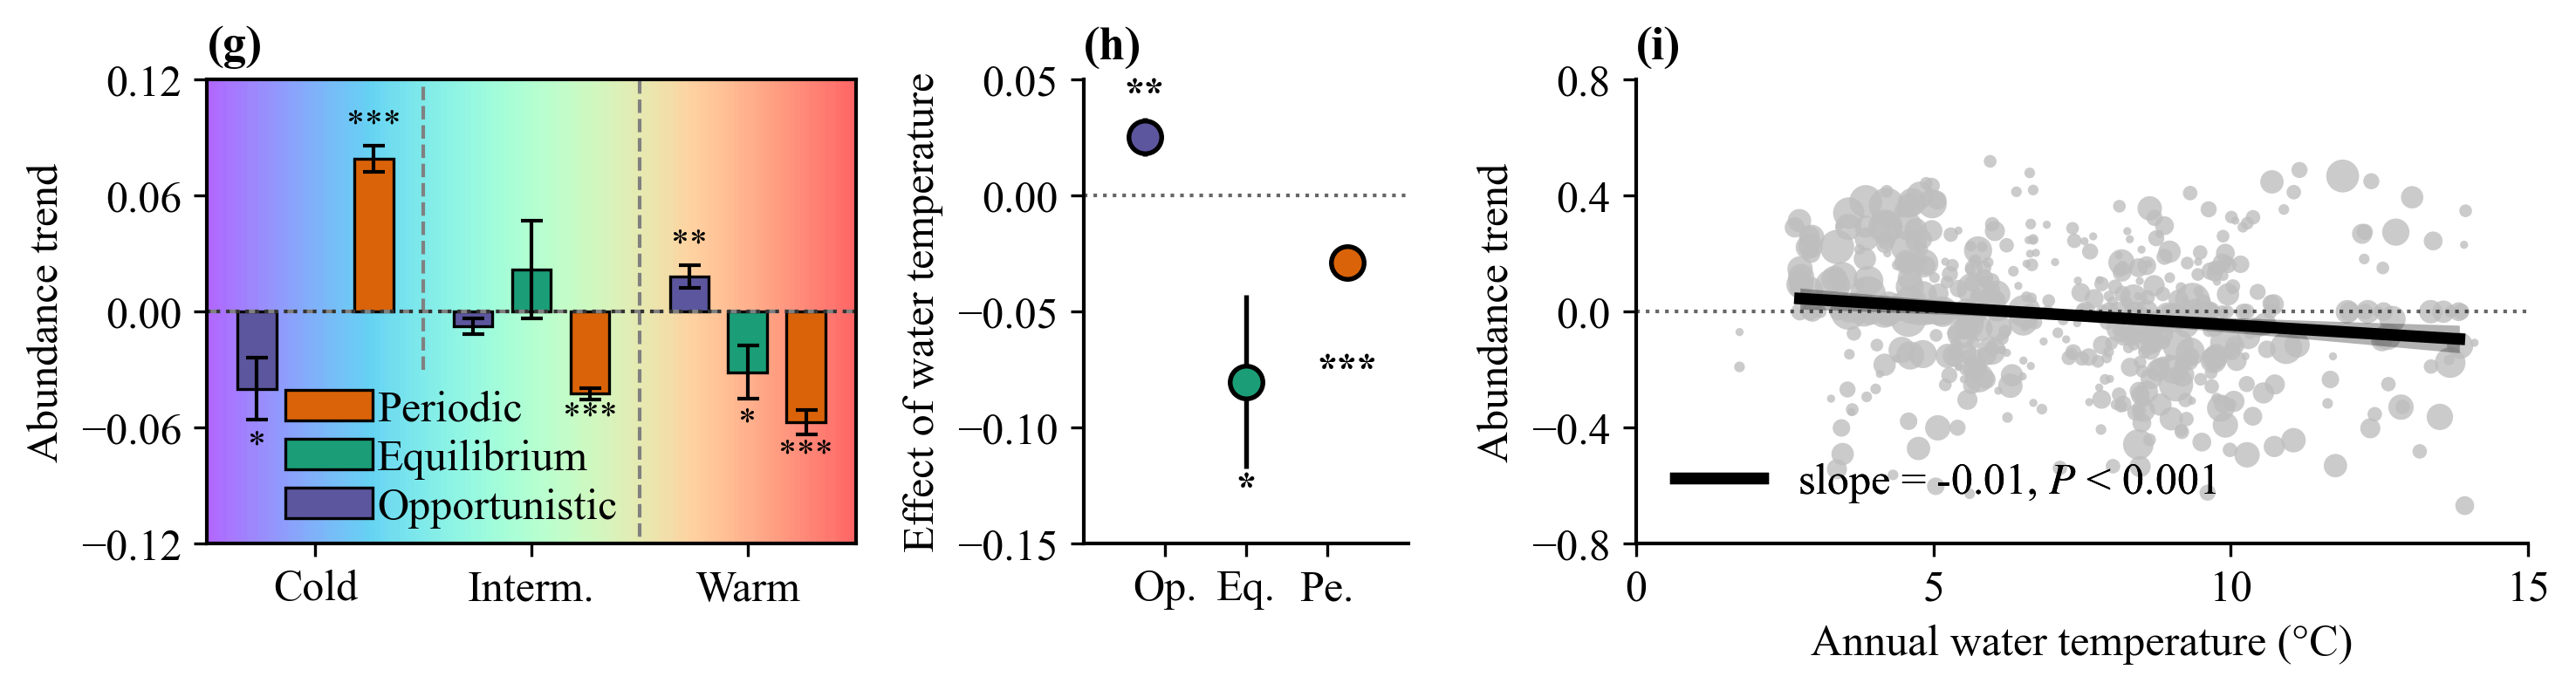

In [ ]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import statsmodels.api as sm
import matplotlib.pyplot as plt
import os
from scipy.stats import ttest_1samp
import cmaps
import matplotlib.gridspec as gridspec

plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 12,
    "axes.linewidth": 1,
    "mathtext.fontset": "stix",  

})
def mean_se_p(sub):
    mean = sub.mean()
    se = sub.std(ddof=1) / np.sqrt(len(sub))
    _, p = ttest_1samp(sub, 0.0)
    return mean, se, p

def p_to_star(p):
    if p < 0.001: return "***"
    elif p < 0.01: return "**"
    elif p < 0.05: return "*"
    else: return ""

fig = plt.figure(figsize=(10,2.8),dpi=300)  
gs = fig.add_gridspec(1,3,width_ratios=[8,4,11])

ax1 = fig.add_subplot(gs[0])  
ax2 = fig.add_subplot(gs[1])
ax3 = fig.add_subplot(gs[2])

ax = ax1
file = r"D:\NC\Data\rivernet\inputdata\Abundance_slope_with_traits_clean.csv"
df = pd.read_csv(file)

cols = ["SiteID","Species","slope_abundance","slope_temp","zone","Strategy"]
df = df[cols].dropna()
df["Species"] = df["Species"].astype(str)
df["zone"] = df["zone"].astype(str)
strategies = ["Opportunistic","Equilibrium","Periodic"]
zones = ["Cold","Intermediate","Warm"]
min_species = 2
min_records = 10  


rows=[]
for zone in zones:
    df_zone = df if zone=="All" else df[df["zone"]==zone]

    for st in strategies:
        sub = df_zone[df_zone["Strategy"]==st]["slope_abundance"]
        sub_all = df_zone[df_zone["Strategy"]==st]
        n_species = sub_all["Species"].nunique()
        n_records = len(sub_all)
        if n_species < min_species or n_records < min_records:
            rows.append([zone, st, np.nan, np.nan, np.nan]) 
            continue

        mean, se, p = mean_se_p(sub)
        rows.append([zone, st, mean, se, p])

res = pd.DataFrame(rows,columns=["Zone","Strategy","Mean","SE","P"])
res["Zone"] = pd.Categorical(res["Zone"], categories=zones, ordered=True)


xmin, xmax = -0.5, 2.5 
ymin, ymax = -0.15, 0.3     
grad = np.tile(np.linspace(0, 1, 800), (200, 1))
cmap = cmaps.MPL_rainbow   
ax.imshow(
    grad,
    extent=[xmin, xmax, ymin, ymax],
    origin="lower",
    cmap=cmap,
    alpha=0.6,
    zorder=0,
    aspect="auto"
)
bar_width = 0.18
gap = 1.5
colors={"Opportunistic":"#5c569e","Equilibrium":"#1b9e77","Periodic":"#da6309"}
offsets={"Opportunistic":-1*bar_width*gap,"Equilibrium":0*bar_width*gap,"Periodic":1*bar_width*gap}

handles={}

for _,row in res.iterrows():
    z_idx=zones.index(row["Zone"])
    x=z_idx+offsets[row["Strategy"]]

    bar=ax.bar(x,row["Mean"],width=bar_width,color=colors[row["Strategy"]],
               edgecolor="black",linewidth=0.8,zorder=2)

    ax.errorbar(x,row["Mean"],yerr=row["SE"],fmt="none",ecolor="black",
                elinewidth=1,capsize=3,zorder=3)

    star=p_to_star(row["P"])
    if star!="":
        y=row["Mean"]+(row["SE"]*1.3 if row["Mean"]>=0 else -row["SE"]*1.3)
        ax.text(x,y,star,ha="center",va="bottom" if row["Mean"]>=0 else "top",fontsize=10)

    if row["Strategy"] not in handles:
        handles[row["Strategy"]] = bar
ax.axhline(0,ls="--",c="gray",lw=1)
ax.vlines(0.5, -0.03, 5, colors="gray", linestyles="--", linewidth=1)
ax.vlines(1.5, -5, 5, colors="gray", linestyles="--", linewidth=1)

ax.set_xticks(range(len(zones)))
ax.set_xticklabels(["Cold","Interm.","Warm"])
ax.set_ylabel("Abundance trend")

order = ["Periodic","Equilibrium", "Opportunistic"]
ax.legend(
    [handles[k] for k in order if k in handles],
    [k for k in order if k in handles],
    frameon=False,
    loc="lower left",
    bbox_to_anchor=(0.06, -0.05),   
    markerscale=0.1,
    handletextpad=0.1,
    labelspacing=0.2   
)
ax.set_title("(g)",loc="left",fontsize=13,fontweight="bold")
ax.set_ylim(-0.12,0.12)
ax.set_yticks([-0.12,-0.06,0,0.06,0.12])
ax.axhline(0,color="black",lw=1,ls=":",alpha=0.6)

#######################################################################
# =========================== 图 (b) ==========================
ax = ax2   

FILE_AB=r"D:\NC\Data\rivernet\inputdata\Abundance_slope_with_traits_clean.csv"
STRATEGIES=["Opportunistic","Equilibrium","Periodic"]
TARGET_TERM="mean_temp_z"
COLORS={"Opportunistic":"#5c569e","Equilibrium":"#1b9e77","Periodic":"#da6309"}
df=pd.read_csv(FILE_AB)
df["Species"]=df["Species"].astype(str)

cols=["slope_abundance","slope_temp","elevation","HFP_mean","mean_temp",
      "mean_flow","mean_salinity","mean_organic"]
df[cols]=df[cols].apply(pd.to_numeric,errors="coerce")
df=df.dropna(subset=cols+["Species","Protocol"])

for c in ["slope_temp","elevation","HFP_mean","mean_temp","mean_flow","mean_salinity","mean_organic"]:
    df[c+"_z"]=(df[c]-df[c].mean())/df[c].std()
def fit_mixedlm(d):
    f = (
        "slope_abundance ~ "
        "slope_temp_z + elevation_z + HFP_mean_z + "
        "mean_temp_z + mean_flow_z + mean_salinity_z + mean_organic_z"
    )
    vc = {}
    if "Protocol" in d.columns and d["Protocol"].nunique() > 1:
        vc["Protocol"] = "0 + C(Protocol)"
    if "HYBAS_ID" in d.columns and d["HYBAS_ID"].nunique() > 1:
        vc["HYBAS_ID"] = "0 + C(HYBAS_ID)"

    if len(vc) == 0:
        vc = None
    return smf.mixedlm(
        f,
        data=d,
        groups=d["Species"],  
        vc_formula=vc
    ).fit(
        reml=True,
        method="powell",
        maxiter=300
    )

def extract(m,t):return m.fe_params.get(t,np.nan),m.bse_fe.get(t,np.nan),m.pvalues.get(t,np.nan)

rows=[]
for st in STRATEGIES:
    sub=df[df["Strategy"]==st]
    if len(sub)<10:  
        rows.append([st,np.nan,np.nan,np.nan]); continue
    try:
        m=fit_mixedlm(sub)
        print("\n" + "=" * 80)
        print(f"MixedLM summary for Strategy = {st}")
        print("=" * 80)
        print(m.summary())
        coef,se,p=extract(m,TARGET_TERM)
        rows.append([st,coef,se,p])
    except:
        rows.append([st,np.nan,np.nan,np.nan])

res_b=pd.DataFrame(rows,columns=["Strategy","Coef","SE","P"])
pos={"Opportunistic":-0.05,"Equilibrium":0,"Periodic":0.05}

def p_to_star(p):return "***"if p<0.001 else"**"if p<0.01 else"*"if p<0.05 else""
def annotate_star(ax,x,y,p):
    st=p_to_star(p)
    if st!="":
        ax.text(x,y+(0.01 if y>=0 else -0.039),st,ha="center",
                va="bottom"if y>=0 else"top",fontsize=11,fontweight="bold")

for _,r in res_b.iterrows():
    if pd.isna(r["Coef"]): continue
    x=pos[r["Strategy"]]

    ax.errorbar(x,r["Coef"],yerr=r["SE"],fmt="o",
        markerfacecolor=COLORS[r["Strategy"]],
        markeredgecolor="black",markeredgewidth=1.3,
        markersize=9,ecolor="black",elinewidth=1.3,
        capsize=0,zorder=3)
    annotate_star(ax,x,r["Coef"],r["P"])

ax.set_xlim(-0.08,0.08)
ax.set_ylim(-0.15,0.05)
ax.set_xticks([-0.04,0,0.04])
ax.set_xticklabels(["Op.","Eq.","Pe."])  
ax.set_yticks([-0.15,-0.10,-0.05,0,0.05])
ax.axhline(0,color="black",lw=1,ls=":",alpha=0.6)

ax.set_ylabel("Effect of water temperature")
ax.set_title("(h)",loc="left",fontsize=13,fontweight="bold")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

#######################################################################
# =========================== 图 (c)==========================
#######################################################################
ax = ax3

folder=r"D:\NC\Data\rivernet\inputdata"
df=pd.read_csv(folder+"/Abundance_slope_with_traits_clean.csv")
sp="Lota lota"
sub=df[(df["Species"]==sp)]
sub["n_obs"]=sub["n_obs"].fillna(1)

s_min,s_max=5,100;n_all=sub["n_obs"].values
n_norm=(n_all-n_all.min())/(n_all.max()-n_all.min())if n_all.max()>n_all.min()else np.ones_like(n_all)
sizes=s_min+n_norm*(s_max-s_min)

x=sub["mean_temp"].values;y=sub["slope_abundance"].values
mask=(~np.isnan(x))&(~np.isnan(y));x,y=x[mask],y[mask]

ax.scatter(x,y,s=sizes[mask],color="#bebebe",alpha=0.8,zorder=1,linewidths=0)
X=sm.add_constant(x);model=sm.OLS(y,X).fit()
x_pred=np.linspace(np.percentile(x,1),np.percentile(x,99),200)
pred=model.get_prediction(sm.add_constant(x_pred)).summary_frame(alpha=0.05)
y_mean,y_low,y_high=pred["mean"],pred["mean_ci_lower"],pred["mean_ci_upper"]

slope=model.params[1];p_val=model.pvalues[1]
if p_val < 0.001:
    p_str = "$P$ < 0.001"
elif p_val < 0.01:
    p_str = "$P$ < 0.01"
elif p_val < 0.05:
    p_str = "$P$ < 0.05"
else:
    p_str = f"$P$ = {p_val:.2f}"

ax.plot(
    x_pred,
    y_mean,
    color="black",
    lw=3.2,
    zorder=4,
    label=f"slope = {slope:.2f}, {p_str}"
)
ax.fill_between(x_pred,y_low,y_high,color="black",alpha=0.3,zorder=3,linewidth=0)
ax.axhline(0,color="black",lw=1,ls=":",alpha=0.6)
ax.set_xlabel("Annual water temperature (°C)")
ax.set_ylabel("Abundance trend")
ax.set_xlim(0,15)
ax.set_xticks([0,5,10,15])
ax.set_ylim(-0.8,0.8)
ax.set_yticks([-0.8,-0.4,0,0.4,0.8])
ax.set_title("(i)",loc="left",fontsize=13,fontweight="bold")

legend_line=ax.legend(frameon=False,fontsize=12,loc="lower left")
ax.add_artist(legend_line)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


#######################################################################
plt.tight_layout()
plt.savefig(r"C:\Users\Lenovo\Desktop\6g-i.png",dpi=300)
plt.show()


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_255304\241636015.py:43: DtypeWarning: Columns (18) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_255304\241636015.py:131: DtypeWarning: Columns (18) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(FILE_AB)
d:\software1\anaconda3\envs\newbase\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)



MixedLM summary for Group = Resident
            Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: slope_abundance
No. Observations: 7904    Method:             REML           
No. Groups:       17      Scale:              0.0631         
Min. group size:  1       Log-Likelihood:     -390.2360      
Max. group size:  1428    Converged:          Yes            
Mean group size:  464.9                                      
-------------------------------------------------------------
                   Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------
Intercept          -0.019    0.009 -2.052 0.040 -0.036 -0.001
slope_temp_z        0.009    0.003  3.225 0.001  0.004  0.015
elevation_z        -0.009    0.004 -2.171 0.030 -0.017 -0.001
HFP_mean_z         -0.001    0.004 -0.281 0.779 -0.008  0.006
mean_temp_z         0.015    0.007  2.115 0.034  0.001  0.029
mean_flow_z         0.004    0.003  1.486 0.

d:\software1\anaconda3\envs\newbase\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_255304\241636015.py:237: DtypeWarning: Columns (18) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv(folder+"/Abundance_slope_with_traits_clean.csv")
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_255304\241636015.py:240: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub["n_obs"]=sub["n_obs"].fillna(1)



MixedLM summary for Group = Migratory
            Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: slope_abundance
No. Observations: 8111    Method:             REML           
No. Groups:       9       Scale:              0.0594         
Min. group size:  8       Log-Likelihood:     -167.4288      
Max. group size:  3340    Converged:          Yes            
Mean group size:  901.2                                      
-------------------------------------------------------------
                   Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------
Intercept          -0.017    0.012 -1.450 0.147 -0.041  0.006
slope_temp_z       -0.006    0.003 -1.882 0.060 -0.012  0.000
elevation_z         0.004    0.004  1.016 0.309 -0.004  0.011
HFP_mean_z          0.012    0.004  3.153 0.002  0.004  0.019
mean_temp_z        -0.031    0.007 -4.828 0.000 -0.044 -0.019
mean_flow_z         0.010    0.004  2.752 0

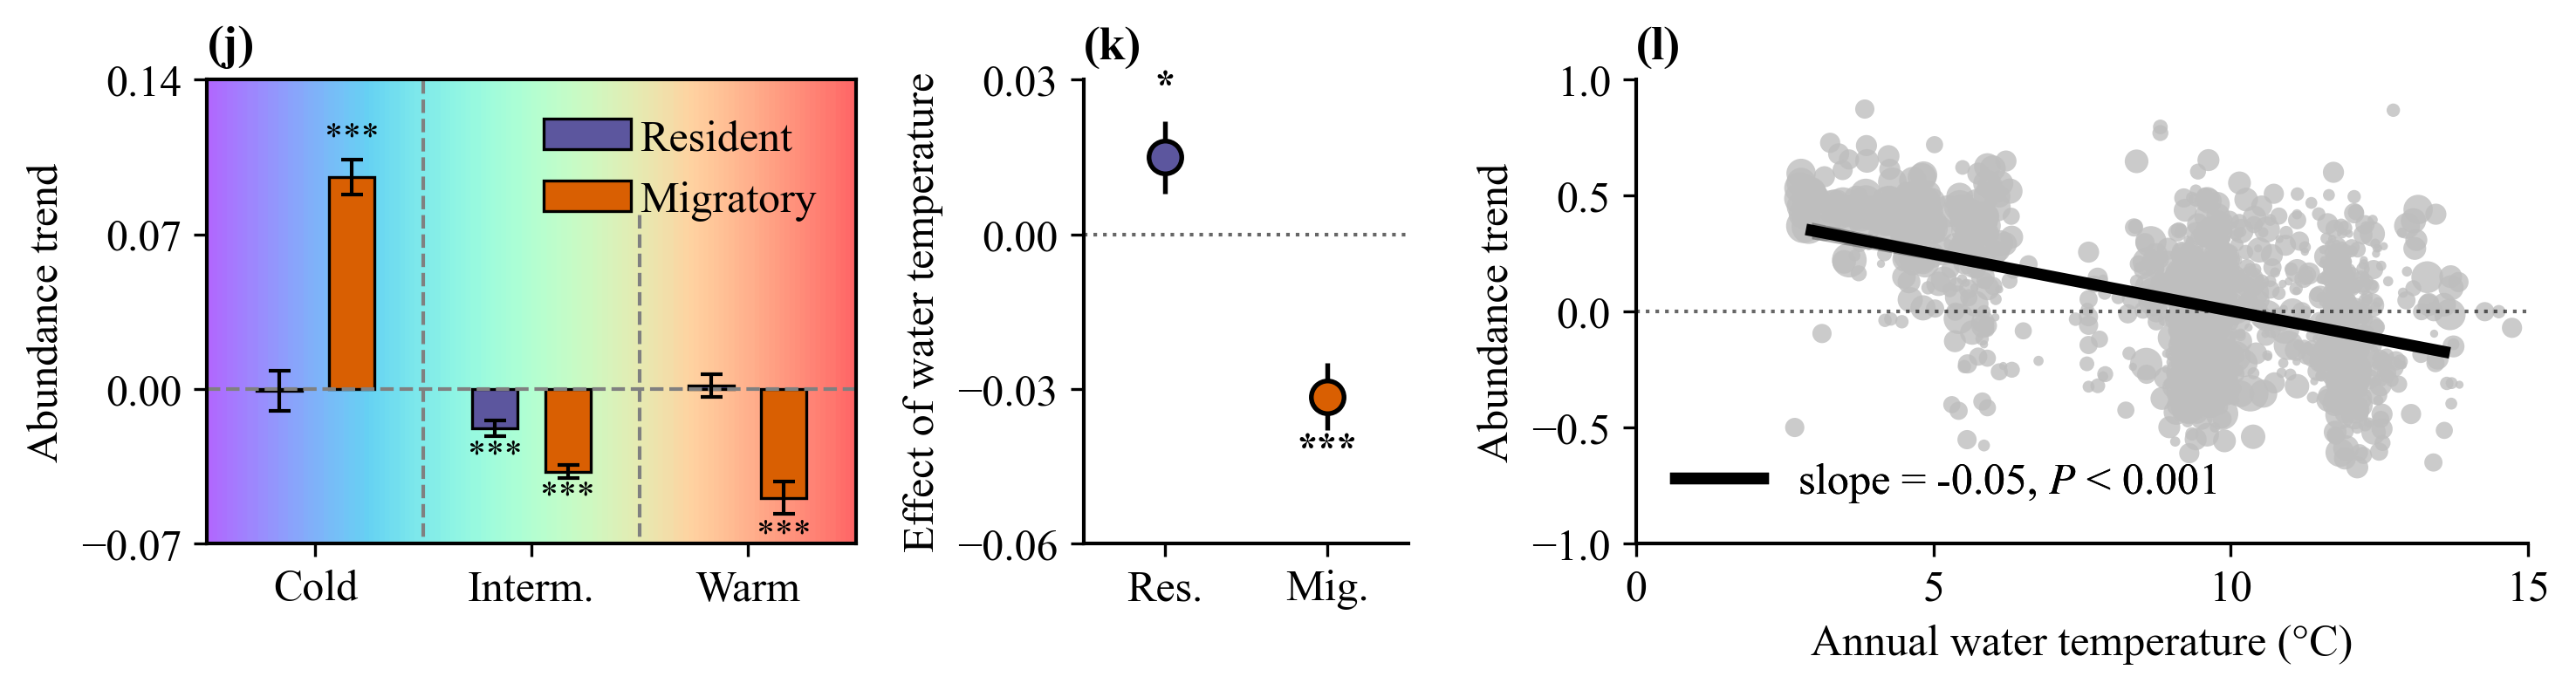

In [ ]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import statsmodels.api as sm
import matplotlib.pyplot as plt
import os
from scipy.stats import ttest_1samp
import cmaps
import matplotlib.gridspec as gridspec

plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 12,
    "axes.linewidth": 1,
    "mathtext.fontset": "stix",  

})

def mean_se_p(sub):
    mean = sub.mean()
    se = sub.std(ddof=1) / np.sqrt(len(sub))
    _, p = ttest_1samp(sub, 0.0)
    return mean, se, p

def p_to_star(p):
    if p < 0.001: return "***"
    elif p < 0.01: return "**"
    elif p < 0.05: return "*"
    else: return ""

fig = plt.figure(figsize=(10,2.8),dpi=300)  
gs = fig.add_gridspec(1,3,width_ratios=[8,4,11])

ax1 = fig.add_subplot(gs[0])  
ax2 = fig.add_subplot(gs[1])
ax3 = fig.add_subplot(gs[2])

# ================= (a)=================
ax = ax1   

file = r"D:\NC\Data\rivernet\inputdata\Abundance_slope_with_traits_clean.csv"
df = pd.read_csv(file)
cols = ["SiteID","Species","slope_abundance","slope_temp","zone","Migratory"]
df = df[cols].dropna()
df["Species"] = df["Species"].astype(str)
df["zone"] = df["zone"].astype(str)
df["Migratory"] = df["Migratory"].astype(str).str.strip().str.upper().map({"TRUE":1,"FALSE":0})
df = df.dropna(subset=["Migratory"])
df["Migratory"] = df["Migratory"].astype(int)
df["Group"] = df["Migratory"].map({0:"Resident", 1:"Migratory"})  

groups = ["Resident","Migratory"]
zones = ["Cold","Intermediate","Warm"]
rows=[]
for zone in zones:
    df_zone = df if zone=="All" else df[df["zone"]==zone]
    for st in groups:
        sub = df_zone[df_zone["Group"]==st]["slope_abundance"]
        if len(sub)==0:
            rows.append([zone,st,np.nan,np.nan,np.nan])
            continue
        mean,se,p = mean_se_p(sub)
        rows.append([zone,st,mean,se,p])

res = pd.DataFrame(rows,columns=["Zone","Group","Mean","SE","P"])
res["Zone"] = pd.Categorical(res["Zone"],categories=zones,ordered=True)
res = res.sort_values("Zone")
xmin,xmax=-0.5,2.5
ymin,ymax=-0.08,0.15
grad=np.tile(np.linspace(0,1,800),(200,1))
cmap=cmaps.MPL_rainbow

ax.imshow(grad,extent=[xmin,xmax,ymin,ymax],origin="lower",
          cmap=cmap,alpha=0.6,zorder=0,aspect="auto")

bar_width=0.21; gap=0.8
colors={"Resident":"#5c569e","Migratory":"#d95f02"}
offsets={"Resident":-bar_width*gap,"Migratory":bar_width*gap}
handles={}

for _,row in res.iterrows():
    zone_idx = zones.index(row["Zone"])
    x = zone_idx + offsets[row["Group"]]

    bar=ax.bar(x,row["Mean"],width=bar_width,color=colors[row["Group"]],
               edgecolor="black",linewidth=0.8,zorder=2)

    ax.errorbar(x,row["Mean"],yerr=row["SE"],fmt="none",
                ecolor="black",elinewidth=1,capsize=3,zorder=3)

    star=p_to_star(row["P"])
    if star!="":
        offset=row["SE"]*1.3
        yy = row["Mean"]+offset if row["Mean"]>=0 else row["Mean"]-offset
        ax.text(x,yy,star,ha="center",
                va="bottom" if row["Mean"]>=0 else "top",fontsize=10)

    if row["Group"] not in handles: handles[row["Group"]] = bar

ax.axhline(0,linestyle="--",color="gray",linewidth=1)
ax.vlines(0.5,-5,5,colors="gray",linestyles="--",linewidth=1)
ax.vlines(1.5,-5,0.08,colors="gray",linestyles="--",linewidth=1)

ax.set_xticks(range(len(zones)))
ax.set_xticklabels(["Cold","Interm.","Warm"])
ax.set_ylabel("Abundance trend")

ax.legend(handles.values(),
          handles.keys(),
          frameon=False,loc="upper right",
        #   bbox_to_anchor=(-0.04,0.00),
          markerscale=0.3,handletextpad=0.2)

ax.set_title("(j)",loc="left",fontsize=13,fontweight="bold")
ax.set_ylim(-0.07,0.14)
ax.set_yticks([-0.07,0,0.07,0.14])

# ===================== (b) =====================
ax = ax2

import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

FILE_AB = r"D:\NC\Data\rivernet\inputdata\Abundance_slope_with_traits_clean.csv"
groups = ["Resident", "Migratory"]          
TARGET_TERM = "mean_temp_z"
COLORS = {"Resident":"#5c569e","Migratory":"#d95f02"}

df = pd.read_csv(FILE_AB)
cols = ["SiteID","Species","slope_abundance","slope_temp","zone",
        "elevation","HFP_mean","mean_temp","mean_flow","mean_salinity",
        "mean_organic","Protocol","Migratory",'HYBAS_ID']
df = df[cols].dropna()
df["Species"] = df["Species"].astype(str)
df["Migratory"] = df["Migratory"].astype(str).str.strip().str.upper().map({"TRUE":1,"FALSE":0})
df = df.dropna(subset=["Migratory"])
df["Migratory"] = df["Migratory"].astype(int)
df["Group"] = df["Migratory"].map({0:"Resident",1:"Migratory"}) 

num_cols=["slope_abundance","slope_temp","elevation","HFP_mean",
          "mean_temp","mean_flow","mean_salinity","mean_organic"]
df[num_cols] = df[num_cols].apply(pd.to_numeric,errors="coerce")
df = df.dropna(subset=num_cols+["Group","zone"]).copy()

for c in ["slope_temp","elevation","HFP_mean","mean_temp","mean_flow","mean_salinity","mean_organic"]:
    df[c+"_z"] = (df[c]-df[c].mean())/df[c].std()

def fit_mixedlm(d):
    f = (
        "slope_abundance ~ "
        "slope_temp_z + elevation_z + HFP_mean_z + "
        "mean_temp_z + mean_flow_z + mean_salinity_z + mean_organic_z"
    )
    vc = {}
    if "Protocol" in d.columns and d["Protocol"].nunique() > 1:
        vc["Protocol"] = "0 + C(Protocol)"
    if "HYBAS_ID" in d.columns and d["HYBAS_ID"].nunique() > 1:
        vc["HYBAS_ID"] = "0 + C(HYBAS_ID)"

    if len(vc) == 0:
        vc = None
    return smf.mixedlm(
        f,
        data=d,
        groups=d["Species"],  
        vc_formula=vc
    ).fit(
        reml=True,
        method="powell",
        maxiter=300
    )

def extract(m,t):return m.fe_params.get(t,np.nan),m.bse_fe.get(t,np.nan),m.pvalues.get(t,np.nan)

rows=[]
for st in groups:
    sub=df[df["Group"]==st]
    if len(sub)<10:
        rows.append([st,np.nan,np.nan,np.nan]); continue
    try:
        m=fit_mixedlm(sub)
        print("\n" + "="*80)
        print(f"MixedLM summary for Group = {st}")
        print("="*80)
        print(m.summary())
        coef,se,p = extract(m,TARGET_TERM)
        rows.append([st,coef,se,p])
    except:
        rows.append([st,np.nan,np.nan,np.nan])

res_b=pd.DataFrame(rows,columns=["Group","Coef","SE","P"])
pos={"Resident":-0.03,"Migratory":0.03}

def p_to_star(p):
    return "***" if p<0.001 else "**" if p<0.01 else "*" if p<0.05 else ""

def annotate_star(ax,x,y,p):
    st=p_to_star(p)
    if st!="":
        ax.text(x, y+(0.01 if y>=0 else -0.007), st,
                ha="center", va="bottom" if y>=0 else "top",
                fontsize=11, fontweight="bold")

for _,row in res_b.iterrows():
    if pd.isna(row["Coef"]) or pd.isna(row["SE"]): continue
    x=pos[row["Group"]]
    ax.errorbar(
        x,row["Coef"],yerr=row["SE"],fmt="o",
        markerfacecolor=COLORS[row["Group"]],
        markeredgecolor="black",markeredgewidth=1.3,
        markersize=9,ecolor="black",elinewidth=1.3,
        capsize=0,zorder=3
    )
    annotate_star(ax,x,row["Coef"],row["P"])

ax.axhline(0,color="black",lw=1,ls=":",alpha=0.6)

ax.set_xlim(-0.06,0.06)
ax.set_xticks([-0.03,0.03])
ax.set_xticklabels(["Res.","Mig."])
ax.set_ylim(-0.06,0.03)
ax.set_yticks([-0.06,-0.03,0,0.03])

ax.set_ylabel("Effect of water temperature")
ax.set_title("(k)",loc="left",fontsize=13,fontweight="bold")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

#######################################################################
# =========================== 图 (c)==========================
#######################################################################
ax = ax3

folder=r"D:\NC\Data\rivernet\inputdata"
df=pd.read_csv(folder+"/Abundance_slope_with_traits_clean.csv")
sp="Salmo salar"
sub=df[(df["Species"]==sp)]
sub["n_obs"]=sub["n_obs"].fillna(1)

s_min,s_max=5,100;n_all=sub["n_obs"].values
n_norm=(n_all-n_all.min())/(n_all.max()-n_all.min())if n_all.max()>n_all.min()else np.ones_like(n_all)
sizes=s_min+n_norm*(s_max-s_min)

x=sub["mean_temp"].values;y=sub["slope_abundance"].values
mask=(~np.isnan(x))&(~np.isnan(y));x,y=x[mask],y[mask]

ax.scatter(x,y,s=sizes[mask],color="#bebebe",alpha=0.8,zorder=1,linewidths=0)
X=sm.add_constant(x);model=sm.OLS(y,X).fit()
x_pred=np.linspace(np.percentile(x,1),np.percentile(x,99),200)
pred=model.get_prediction(sm.add_constant(x_pred)).summary_frame(alpha=0.05)
y_mean,y_low,y_high=pred["mean"],pred["mean_ci_lower"],pred["mean_ci_upper"]

slope=model.params[1];p_val=model.pvalues[1]
if p_val < 0.001:
    p_str = "$P$ < 0.001"
elif p_val < 0.01:
    p_str = "$P$ < 0.01"
elif p_val < 0.05:
    p_str = "$P$ < 0.05"
else:
    p_str = f"$P$ = {p_val:.2f}"

ax.plot(
    x_pred,
    y_mean,
    color="black",
    lw=3.2,
    zorder=4,
    label=f"slope = {slope:.2f}, {p_str}"
)
ax.fill_between(x_pred,y_low,y_high,color="black",alpha=0.3,zorder=3,linewidth=0)
ax.axhline(0,color="black",lw=1,ls=":",alpha=0.6)
ax.set_xlabel("Annual water temperature (°C)")
ax.set_ylabel("Abundance trend")
ax.set_xlim(0,15)
ax.set_xticks([0,5,10,15])
ax.set_ylim(-1,1)
ax.set_yticks([-1,-0.5,0,0.5,1])
ax.set_title("(l)",loc="left",fontsize=13,fontweight="bold")

legend_line=ax.legend(frameon=False,fontsize=12,loc="lower left")
ax.add_artist(legend_line)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


#######################################################################
plt.tight_layout()
plt.savefig(r"C:\Users\Lenovo\Desktop\6j-l.png",dpi=300)
plt.show()
